In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer


import warnings
warnings.filterwarnings('ignore')

In [46]:
df = pd.read_csv('C:\\Users\\user pc\\Downloads\\Autism\\csv_result-Autism-Adult-Data.csv')
print(df.head())

   id  A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0   1         1         1         1         1         0         0         1   
1   2         1         1         0         1         0         0         0   
2   3         1         1         0         1         1         0         1   
3   4         1         1         0         1         0         0         1   
4   5         1         0         0         0         0         0         0   

   A8_Score  A9_Score  ...  gender       ethnicity jundice austim  \
0         1         0  ...       f  White-European      no     no   
1         1         0  ...       m          Latino      no    yes   
2         1         1  ...       m          Latino     yes    yes   
3         1         0  ...       f  White-European      no    yes   
4         1         0  ...       f               ?      no     no   

   contry_of_res used_app_before result     age_desc  relation Class/ASD  
0  United States              no   

In [47]:
df.shape


(704, 22)

In [48]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               704 non-null    int64 
 1   A1_Score         704 non-null    int64 
 2   A2_Score         704 non-null    int64 
 3   A3_Score         704 non-null    int64 
 4   A4_Score         704 non-null    int64 
 5   A5_Score         704 non-null    int64 
 6   A6_Score         704 non-null    int64 
 7   A7_Score         704 non-null    int64 
 8   A8_Score         704 non-null    int64 
 9   A9_Score         704 non-null    int64 
 10  A10_Score        704 non-null    int64 
 11  age              704 non-null    object
 12  gender           704 non-null    object
 13  ethnicity        704 non-null    object
 14  jundice          704 non-null    object
 15  austim           704 non-null    object
 16  contry_of_res    704 non-null    object
 17  used_app_before  704 non-null    ob

In [49]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,704.0,352.500000,203.371581,1.0,176.75,352.5,528.25,704.0
A1_Score,704.0,0.721591,0.448535,0.0,0.00,1.0,1.00,1.0
A2_Score,704.0,0.453125,0.498152,0.0,0.00,0.0,1.00,1.0
A3_Score,704.0,0.457386,0.498535,0.0,0.00,0.0,1.00,1.0
A4_Score,704.0,0.495739,0.500337,0.0,0.00,0.0,1.00,1.0
A5_Score,704.0,0.498580,0.500353,0.0,0.00,0.0,1.00,1.0
A6_Score,704.0,0.284091,0.451301,0.0,0.00,0.0,1.00,1.0
A7_Score,704.0,0.417614,0.493516,0.0,0.00,0.0,1.00,1.0
A8_Score,704.0,0.649148,0.477576,0.0,0.00,1.0,1.00,1.0
A9_Score,704.0,0.323864,0.468281,0.0,0.00,0.0,1.00,1.0


In [50]:
df['ethnicity'].value_counts()


ethnicity
White-European     233
Asian              123
?                   95
Middle Eastern      92
Black               43
South Asian         36
Others              30
Latino              20
Hispanic            13
Pasifika            12
Turkish              6
others               1
Name: count, dtype: int64

In [51]:
df['relation'].value_counts()


relation
Self                        522
?                            95
Parent                       50
Relative                     28
Others                        5
Health care professional      4
Name: count, dtype: int64

In [52]:
df = df.replace({'yes':1, 'no':0, '?':'Others', 'others':'Others'})


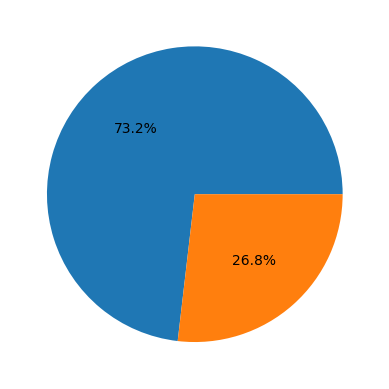

In [53]:
plt.pie(df['Class/ASD'].value_counts().values, autopct='%1.1f%%')
plt.show()


In [54]:
ints = []
objects = []
floats = []

for col in df.columns:
  if df[col].dtype == int:
    ints.append(col)
  elif df[col].dtype == object:
    objects.append(col)
  else:
    floats.append(col)


In [55]:
if 'id' in ints:
    ints.remove('id')
if 'Class/ASD' in ints:
    ints.remove('Class/ASD')


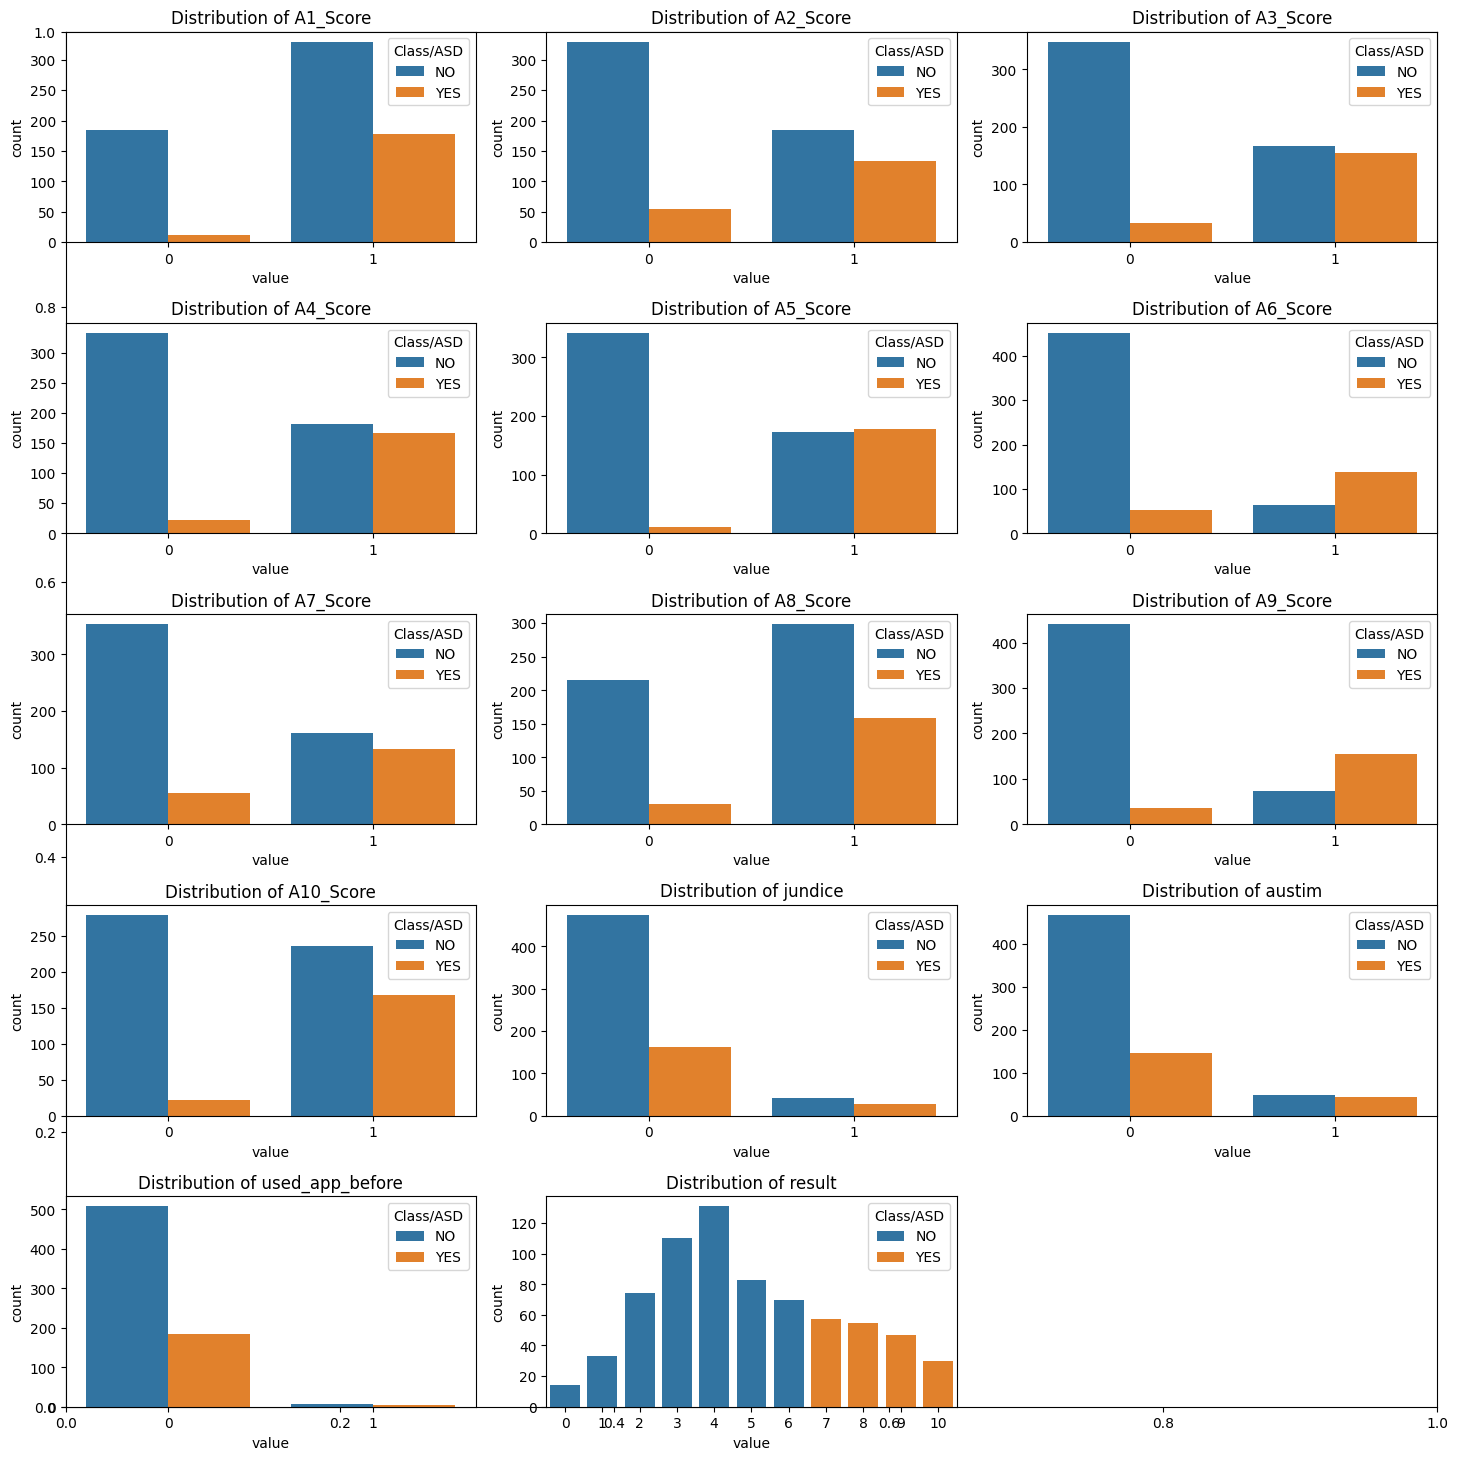

In [56]:
# Convert the data to long-form using melt
df_melted = df.melt(id_vars=['id', 'Class/ASD'], value_vars=ints, var_name='col', value_name='value')

plt.subplots(figsize=(15,15))

for i, col in enumerate(ints):
  plt.subplot(5,3,i+1)
  # Use the melted DataFrame and specify x and hue
  sb.countplot(x='value', hue='Class/ASD', data=df_melted[df_melted['col'] == col])
  plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

ValueError: num must be an integer with 1 <= num <= 5, not 6

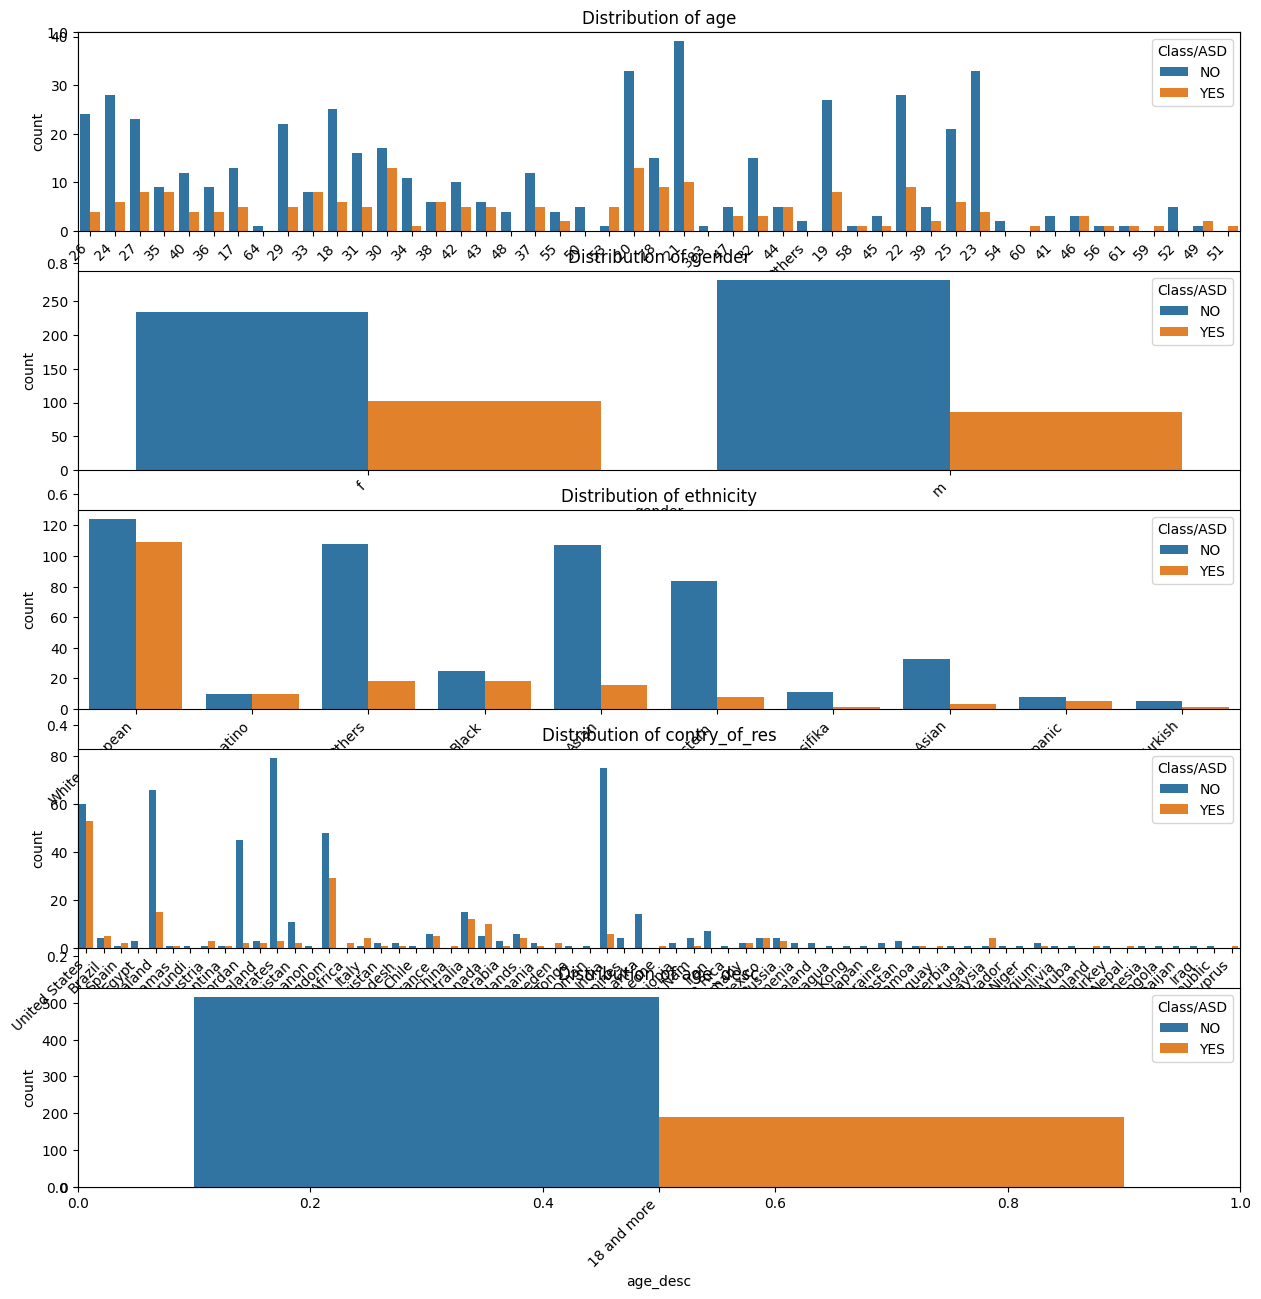

In [57]:

plt.subplots(figsize=(15, 15))  # Adjust figure size as needed

for i, col in enumerate(objects):
    plt.subplot(5, 1, i + 1)  # Adjust subplot grid as needed
    sb.countplot(x=col, hue='Class/ASD', data=df)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right') # Rotates x-axis labels for better readability

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(15,5))
sb.countplot(data=df, x='contry_of_res', hue='Class/ASD')
plt.xticks(rotation=90)
plt.show()


In [ ]:
plt.subplots(figsize=(15,5))

for i, col in enumerate(floats):
  plt.subplot(1,2,i+1)
  sb.distplot(df[col])
plt.tight_layout()
plt.show()


In [ ]:
plt.subplots(figsize=(15,5))

for i, col in enumerate(floats):
  plt.subplot(1,2,i+1)
  sb.boxplot(df[col])
plt.tight_layout()
plt.show()


In [ ]:
df = df[df['result']>-5]
df.shape


In [ ]:
# This functions make groups by taking
# the age as a parameter
def convertAge(age):
    if age < 4:
        return 'Toddler'
    elif age < 12:
        return 'Kid'
    elif age < 18:
        return 'Teenager'
    elif age < 40:
        return 'Young'
    else:
        return 'Senior'

df['ageGroup'] = df['age'].apply(convertAge)


In [ ]:
sb.countplot(x=df['ageGroup'], hue=df['Class/ASD'])
plt.show()


In [59]:
def add_feature(data):

  # Creating a column with all values zero
  data['sum_score'] = 0
  for col in data.loc[:,'A1_Score':'A10_Score'].columns:

    # Updating the 'sum_score' value with scores
    # from A1 to A10
    data['sum_score'] += data[col]

  # Creating a random data using the below three columns
  data['ind'] = data['austim'] + data['used_app_before'] + data['jundice']

  return data

df = add_feature(df)


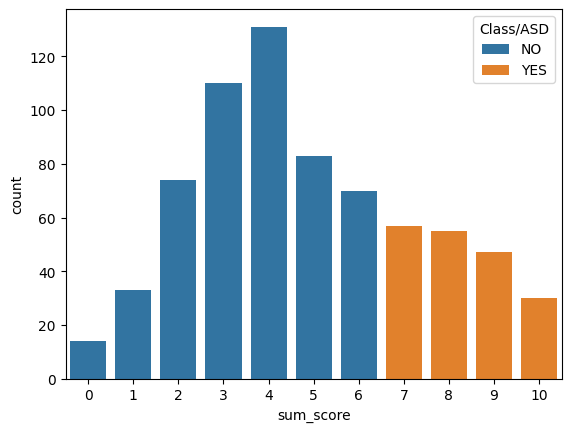

In [60]:
sb.countplot(x=df['sum_score'], hue=df['Class/ASD'])
plt.show()


In [62]:
# Applying log transformations to remove the skewness of the data.
def encode_labels(data):
    for col in data.columns:
      if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
    return data

df = encode_labels(df)

# Log scale age
df['age'] = df['age'].apply(lambda x: np.log(x))
df.head()

,id,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD,sum_score,ind
0,1,1,1,1,1,0,0,1,1,0,...,0,0,64,0,6,0,4,0,6,0
1,2,1,1,0,1,0,0,0,1,0,...,0,1,13,0,5,0,4,0,5,1
2,3,1,1,0,1,1,0,1,1,1,...,1,1,56,0,8,0,2,1,8,2
3,4,1,1,0,1,0,0,1,1,0,...,0,1,64,0,6,0,4,0,6,1
4,5,1,0,0,0,0,0,0,1,0,...,0,0,22,0,2,0,1,0,2,0


OverflowError: cannot convert float infinity to integer

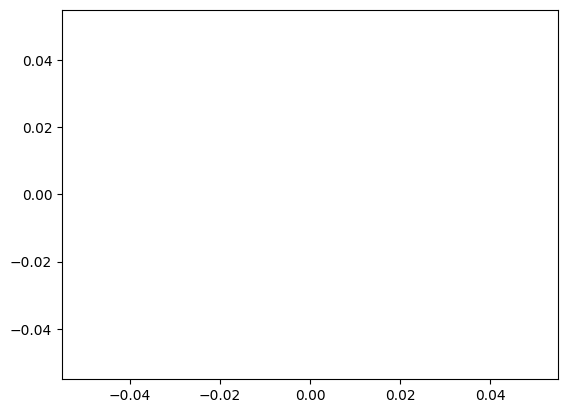

In [63]:
sb.distplot(df['age'])
plt.show()


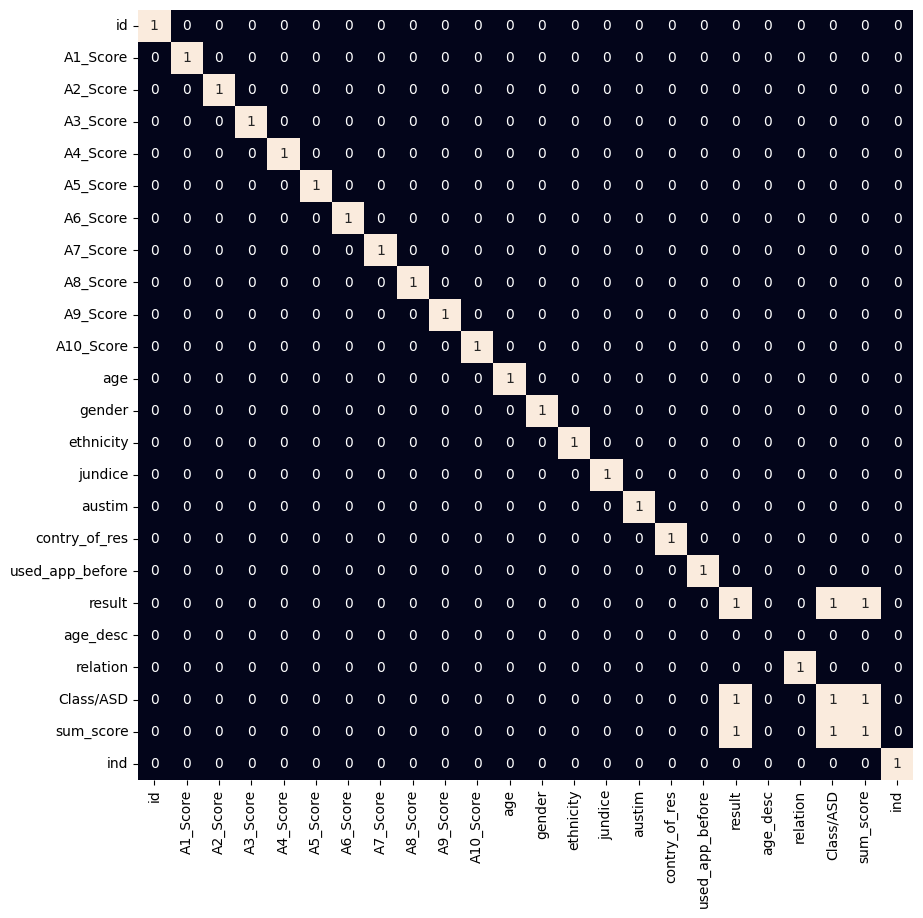

In [64]:
def encode_labels(data):
    for col in data.columns:

      # Here we will check if datatype
      # is object then we will encode it
      if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

    return data

df = encode_labels(df)

# Making a heatmap to visualize the correlation matrix
plt.figure(figsize=(10,10))
sb.heatmap(df.corr() > 0.8, annot=True, cbar=False)
plt.show()


In [66]:
removal = ['id', 'age_desc', 'used_app_before', 'austim']
features = df.drop(removal + ['Class/ASD'], axis=1)
target = df['Class/ASD']


In [67]:
X_train, X_val, Y_train, Y_val = train_test_split(features, target, test_size = 0.2, random_state=10)

# As the data was highly imbalanced we will balance it by adding repetitive rows of minority class.
ros = RandomOverSampler(sampling_strategy='minority',random_state=0)
X, Y = ros.fit_resample(X_train,Y_train)
X.shape, Y.shape


((820, 19), (820,))

In [72]:
# Check and fix X and X_val before scaling
X = np.where(np.isinf(X), np.nan, X)
X_val = np.where(np.isinf(X_val), np.nan, X_val)

# Impute NaN
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
X_val = imputer.transform(X_val)

# Now scale
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_val = scaler.transform(X_val)

In [77]:
models = [
    LogisticRegression(),
    XGBClassifier(),
    SVC(kernel='rbf', probability=True)  # enable probabilities
]


for model in models:
  model.fit(X, Y)

  print(f'{model} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(Y, model.predict(X)))
  print('Validation Accuracy : ', metrics.roc_auc_score(Y_val, model.predict(X_val)))
  print()


LogisticRegression() : 
Training Accuracy :  1.0
Validation Accuracy :  1.0

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  1.0
Validation Accuracy :  1.0

SVC(probability=True) : 
Training Accuracy :  1.0
Validation Accuracy :  0.9904761904761904



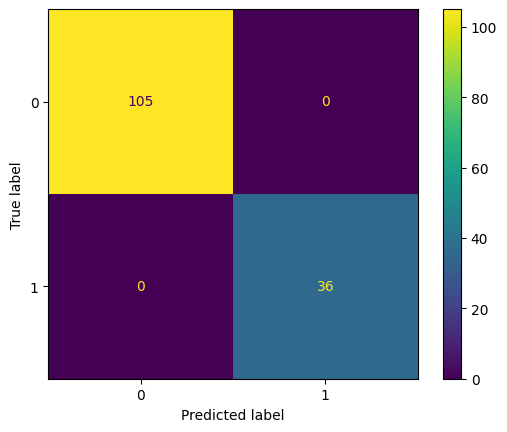

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(models[0], X_val, Y_val)
plt.show()

In [75]:
import joblib

# Save the trained model to disk
joblib.dump(model, 'autism_predictor_model.joblib')

print('Model saved!')



Model saved!


In [79]:
import joblib
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Train Logistic Regression
log_model = LogisticRegression()
log_model.fit(X, Y)
joblib.dump(log_model, 'logistic_model.joblib')  # save model

# Train XGBoost
xgb_model = XGBClassifier()
xgb_model.fit(X, Y)
joblib.dump(xgb_model, 'xgb_model.joblib')  # save model

# Save your preprocessor tools too
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(imputer, 'imputer.joblib')

['imputer.joblib']

In [76]:
# Save scaler and imputer
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(imputer, 'imputer.joblib')


['imputer.joblib']